In [2]:
# Ucitavanje biblioteka
import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt

In [3]:
# Ucitavanje slika i provjera
images = sorted(glob.glob("Slike2/*.jpg"))
print("Broj pronađenih slika:", len(images))

for image in images:
    print(image)

Broj pronađenih slika: 18
Slike2\WIN_20260911_16_22_07_Pro.jpg
Slike2\WIN_20260911_16_22_12_Pro.jpg
Slike2\WIN_20260911_16_22_24_Pro.jpg
Slike2\WIN_20260911_16_22_42_Pro.jpg
Slike2\WIN_20260911_16_22_49_Pro.jpg
Slike2\WIN_20260911_16_22_57_Pro.jpg
Slike2\WIN_20260911_16_23_07_Pro.jpg
Slike2\WIN_20260911_16_23_38_Pro.jpg
Slike2\WIN_20260911_16_23_48_Pro.jpg
Slike2\WIN_20260911_16_24_04_Pro.jpg
Slike2\WIN_20260911_16_24_18_Pro.jpg
Slike2\WIN_20260911_16_24_36_Pro.jpg
Slike2\WIN_20260911_16_24_45_Pro.jpg
Slike2\WIN_20260911_16_24_58_Pro.jpg
Slike2\WIN_20260911_16_25_05_Pro.jpg
Slike2\WIN_20260911_16_25_27_Pro.jpg
Slike2\WIN_20260911_16_25_32_Pro.jpg
Slike2\WIN_20260911_16_25_52_Pro.jpg


In [4]:
# Provjera dimenzija slike
img = cv2.imread(images[0])
print("Dimenzije slike:", img.shape)

Dimenzije slike: (720, 1280, 3)


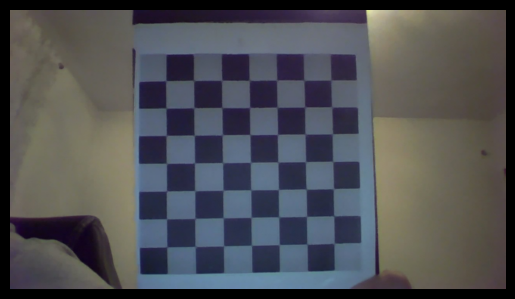

In [5]:
# Prikaz slike i promjena iz BGR u RGB
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [6]:
# Pretvaranje slike u crno bijelu (Brze performanse)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gray.shape)

(720, 1280)


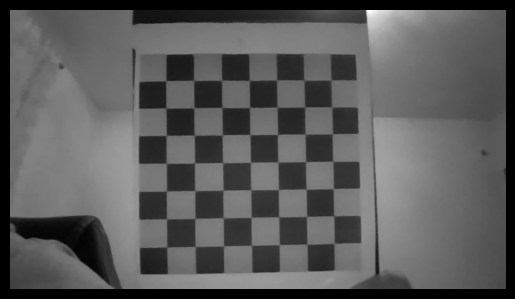

In [7]:
# Prikaz crno bijele slike
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

In [8]:
# Pronalazak kutova (broj unutarnjih kutova 7x7)
chessboard_size = (7, 7)

ret, corners = cv2.findChessboardCornersSB(
    gray,
    chessboard_size,
    None
)

print("Šahovnica pronađena:", ret)

if ret:
    print("Broj pronađenih kutova:", len(corners))

Šahovnica pronađena: True
Broj pronađenih kutova: 49


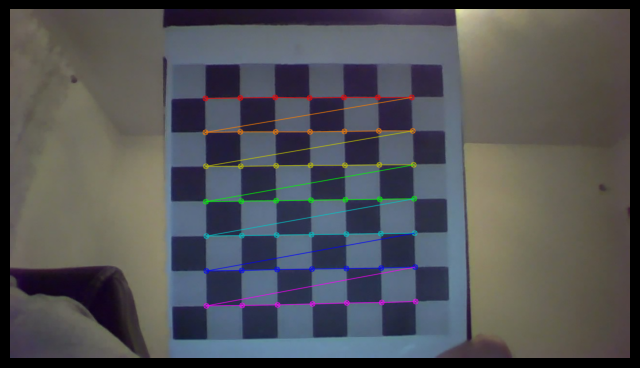

In [9]:
img_corners = img.copy()

cv2.drawChessboardCorners(
    img_corners,
    (7, 7),
    corners,
    ret
)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img_corners, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [10]:
# Generiranje poznatih 3D koordinata (object points) za svih 49 unutarnjih kutova šahovske ploče.
objp = np.zeros((7 * 7, 3), np.float32)

# Formiranje mreže koordinata 7×7, pri čemu je Z koordinata jednaka 0 za sve točke.
objp[:, :2] = np.mgrid[0:7, 0:7].T.reshape(-1, 2)

print(objp[:10])

[[0. 0. 0.]
 [1. 0. 0.]
 [2. 0. 0.]
 [3. 0. 0.]
 [4. 0. 0.]
 [5. 0. 0.]
 [6. 0. 0.]
 [0. 1. 0.]
 [1. 1. 0.]
 [2. 1. 0.]]


In [11]:
# Obrada svih slika i spremanje uspješno detektiranih kutova
objpoints = []
imgpoints = []

for fname in images:

    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, corners = cv2.findChessboardCornersSB(
        gray,
        (7, 7)
    )

    if ret:
        objpoints.append(objp)
        imgpoints.append(corners)

print("Broj uspješnih slika:", len(objpoints))
print("Broj skupova kutova:", len(imgpoints))

Broj uspješnih slika: 18
Broj skupova kutova: 18


In [12]:
# Izračun intrinzičnih i ekstrinzičnih parametara kamere te koeficijenata distorzije.
ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
    objpoints,
    imgpoints,
    gray.shape[::-1],
    None,
    None
)

In [13]:
# Ispis RMS pogreške, matrice kamere i koeficijenata distorzije dobivenih kalibracijom.
print("RMS pogreška:")
print(ret)

print("\nMatrica kamere:")
print(camera_matrix)

print("\nKoeficijenti distorzije:")
print(dist_coeffs)

RMS pogreška:
0.6481562476115239

Matrica kamere:
[[978.74006161   0.         648.13529517]
 [  0.         970.53736462 387.95234887]
 [  0.           0.           1.        ]]

Koeficijenti distorzije:
[[-1.03637813e-03 -3.00590892e-01  3.69433193e-03  2.87298829e-04
   5.04543323e-01]]


In [14]:
# Uklanjanje distorzije sa slike primjenom rezultata kalibracije.
undistorted = cv2.undistort(
    img,
    camera_matrix,
    dist_coeffs
)

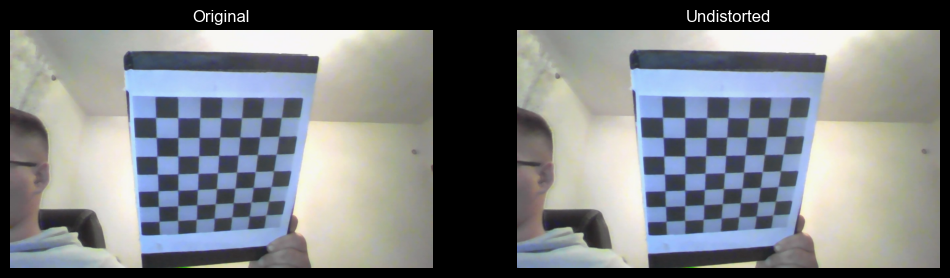

In [15]:
# Prikaz originalne i korigirane slike.
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
plt.title("Undistorted")
plt.axis("off")

plt.show()

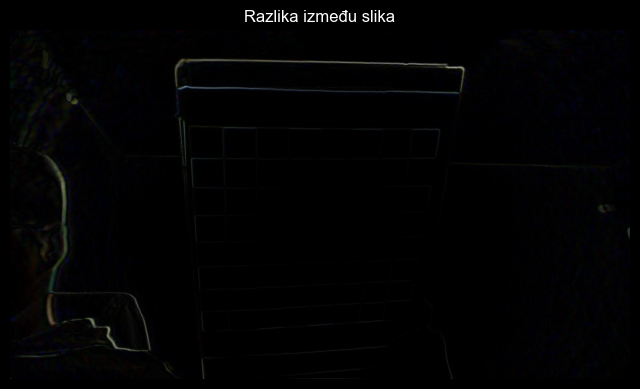

In [16]:
# Vizualizacija razlika između originalne i korigirane slike nakon uklanjanja distorzije
difference = cv2.absdiff(img, undistorted)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(difference, cv2.COLOR_BGR2RGB))
plt.title("Razlika između slika")
plt.axis("off")
plt.show()

In [17]:
# Izračun prosječne reprojekcijske pogreške
mean_error = 0

for i in range(len(objpoints)):

    imgpoints2, _ = cv2.projectPoints(
        objpoints[i],
        rvecs[i],
        tvecs[i],
        camera_matrix,
        dist_coeffs
    )

    error = cv2.norm(
        imgpoints[i],
        imgpoints2,
        cv2.NORM_L2
    ) / len(imgpoints2)

    mean_error += error

print("Prosječna reprojekcijska pogreška:")
print(mean_error / len(objpoints))

Prosječna reprojekcijska pogreška:
0.09041039763356656


In [18]:
# Prikaz ekstrinzičnih parametara
print("rvec:")
print(rvecs[0])

print("\ntvec:")
print(tvecs[0])

rvec:
[[-0.0232822 ]
 [-0.04609265]
 [-0.01291067]]

tvec:
[[-3.41615198]
 [-2.88357816]
 [13.59043158]]
